# Rezultati za članek:
*Impact of Mechanical Stress on Electrochemical Impedance Spectra and Incremental Capacity of the Lithium-Ion Battery*

Poženi prvo file ```install_pybamm.ipynb```, da si naložiš modificirano verzijo PyBaMM-a.

In [1]:
# aktiviraj myenv okolje
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize
from joblib import Parallel, delayed
from scipy.signal import savgol_filter

In [2]:
# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 24,           # Osnovna velikost pisave
    'axes.titlesize': 24,      # Velikost naslova grafa
    'axes.labelsize': 24,      # Velikost pisave na osi
    'xtick.labelsize': 21,     # Velikost številk na x osi
    'ytick.labelsize': 21,     # Velikost številk na y osi
    'legend.fontsize': 22,     # Velikost pisave v legendi
})

Load results

In [3]:
sol_DFN = pybamm.load("NMC_LiC6 results/NMC_LiC6_0Pa_discharge.pkl")
sol_DFN_1 = pybamm.load("NMC_LiC6 results/NMC_LiC6_1MPa_discharge.pkl")
sol_DFN_2 = pybamm.load("NMC_LiC6 results/NMC_LiC6_10MPa_discharge.pkl")
sol_DFN_C = pybamm.load("NMC_LiC6 results/NMC_LiC6_0Pa_charge.pkl")
sol_DFN_1_C = pybamm.load("NMC_LiC6 results/NMC_LiC6_1MPa_charge.pkl")
sol_DFN_2_C = pybamm.load("NMC_LiC6 results/NMC_LiC6_10MPa_charge.pkl")

## OCV

In [ ]:
# model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
#                                         "particle": "Fickian diffusion",
#                                                 },
#                                         )
# param0 = pybamm.ParameterValues("Mohtat2020_Mech") 
# param0.update(
#     {"Hydrostatic stress [Pa]": 0,
#      "Negative electrode partial molar volume [m3.mol-1]": 3.1e-4,
#      },
#     check_already_exists=False ,
    
# )


# param1 = pybamm.ParameterValues("Mohtat2020_Mech") 
# param1.update(
#     {"Hydrostatic stress [Pa]": 1e6,
#      "Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
#     check_already_exists=False  
# )


# param2 = pybamm.ParameterValues("Mohtat2020_Mech") 
# param2.update(
#     {"Hydrostatic stress [Pa]": 1e7,
#      "Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
#     check_already_exists=False  
# )


# var_pts = {
#     "x_n": 30,  # negative electrode
#     "x_s": 20,  # separator
#     "x_p": 30,  # positive electrode
#     "r_n": 25,  # negative particle
#     "r_p": 25,  # positive particle
# }

# experiment = pybamm.Experiment(["Discharge at C/50 until 2.75 V"])
# experiment_C = pybamm.Experiment(["Charge at C/50 until 4.2 V"])

# solver = pybamm.IDAKLUSolver()  


# # discharge battery
# sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
#                               )
# sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
#                               )
# sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
#                               )

# # charge battery
# sim_DFN_0_C = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, experiment=experiment_C, solver=solver)
# sim_DFN_1_C = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, experiment=experiment_C, solver=solver)
# sim_DFN_2_C = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, experiment=experiment_C, solver=solver)

# ######################
# t_eval = [0, 3600]
# # t_eval = np.linspace(0, 0.3, 1000)  
# ######################

# start = time.time()
# sol_DFN = sim_DFN_0.solve(initial_soc=1)
# end = time.time()
# print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN_1 = sim_DFN_1.solve(initial_soc=1)
# end = time.time()
# print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN_2 = sim_DFN_2.solve(initial_soc=1)
# end = time.time()
# print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN_C = sim_DFN_0_C.solve(initial_soc=0)  
# end = time.time()
# print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN_1_C = sim_DFN_1_C.solve(initial_soc=0)
# end = time.time()
# print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

# start = time.time()
# sol_DFN_2_C = sim_DFN_2_C.solve(initial_soc=0)
# end = time.time()
# print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

# sol_DFN.save("NMC_LiC6 results/NMC_LiC6_0Pa_discharge.pkl")
# sol_DFN_1.save("NMC_LiC6 results/NMC_LiC6_1MPa_discharge.pkl")
# sol_DFN_2.save("NMC_LiC6 results/NMC_LiC6_10MPa_discharge.pkl")
# sol_DFN_C.save("NMC_LiC6 results/NMC_LiC6_0Pa_charge.pkl")
# sol_DFN_1_C.save("NMC_LiC6 results/NMC_LiC6_1MPa_charge.pkl")
# sol_DFN_2_C.save("NMC_LiC6 results/NMC_LiC6_10MPa_charge.pkl")

Simulacija DFN_0 zaključena v 3.09 s.
Simulacija DFN_1 zaključena v 1.83 s.
Simulacija DFN_2 zaključena v 1.90 s.


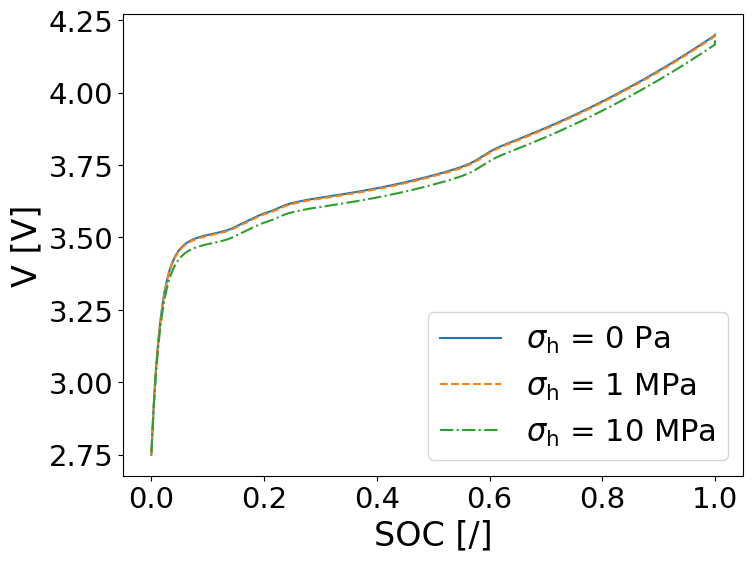

In [17]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

Q_discharged = sol_DFN_C["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_C = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1_C["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1_C = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2_C["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2_C = (Q_discharged / Q_max)

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2
         ]

y_val = [sol_DFN["Battery voltage [V]"].entries, 
         sol_DFN_1["Battery voltage [V]"].entries,
        sol_DFN_2["Battery voltage [V]"].entries,
         ]

# y_val = [sol_DFN["Battery open-circuit voltage [V]"].entries, 
#          sol_DFN_1["Battery open-circuit voltage [V]"].entries,
#         sol_DFN_2["Battery open-circuit voltage [V]"].entries
#          ]


plt.figure(figsize=fig_size)

for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = 0 Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 1 MPa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 10 MPa", 
                                        ][i],
                                linestyle=['-', '--', '-.' ][i]

                                        )
    
# # draw line at soc = 0.5
# plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# # draw line at 3.7156 V
# plt.axhline(y=3.7156, color='gray', linestyle='--', label='V = 3.7156 V')

plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
# plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))
plt.legend()
# plt.grid()

# save to eps
# plt.savefig("NMC_LiC6_OCV.eps", format='eps',dpi= 300, bbox_inches='tight')

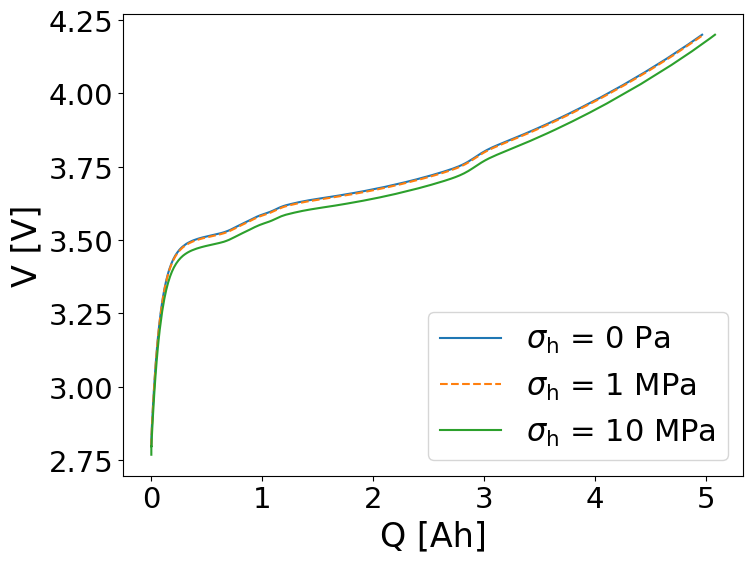

In [28]:
Q_discharged_0Pa = sol_DFN["Discharge capacity [A.h]"].entries
Q_discharged_1MPa = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_discharged_10MPa = sol_DFN_2["Discharge capacity [A.h]"].entries

Q_discharged_0Pa_C = sol_DFN_C["Discharge capacity [A.h]"].entries
Q_discharged_1MPa_C = sol_DFN_1_C["Discharge capacity [A.h]"].entries
Q_discharged_10MPa_C = sol_DFN_2_C["Discharge capacity [A.h]"].entries

x_val = [
        # Q_discharged_0Pa,
        # Q_discharged_1MPa,
        # Q_discharged_10MPa,
        Q_discharged_0Pa_C*(-1),
        Q_discharged_1MPa_C*(-1),
        Q_discharged_10MPa_C*(-1),        
         ]

y_val = [
        # sol_DFN["Battery voltage [V]"].entries, 
        # sol_DFN_1["Battery voltage [V]"].entries,
        # sol_DFN_2["Battery voltage [V]"].entries,
        sol_DFN_C["Battery voltage [V]"].entries, 
        sol_DFN_1_C["Battery voltage [V]"].entries,
        sol_DFN_2_C["Battery voltage [V]"].entries,
         ]


plt.figure(figsize=fig_size)

for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = 0 Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 1 MPa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 10 MPa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 0 Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 1 MPa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = 10 MPa",
                                        ][i],
                                linestyle=['-', '--', '-', '-', '--', '-' ][i]

                                        )
    
# # draw line at soc = 0.5
# plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# # draw line at 3.7156 V
# plt.axhline(y=3.7156, color='gray', linestyle='--', label='V = 3.7156 V')

plt.xlabel("Q [Ah]")
plt.ylabel("V [V]")
# plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))
plt.legend()
# plt.grid()

# save to eps
# plt.savefig("NMC_LiC6_VQ_charge.eps", format='eps',dpi= 300, bbox_inches='tight')

## ICA

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


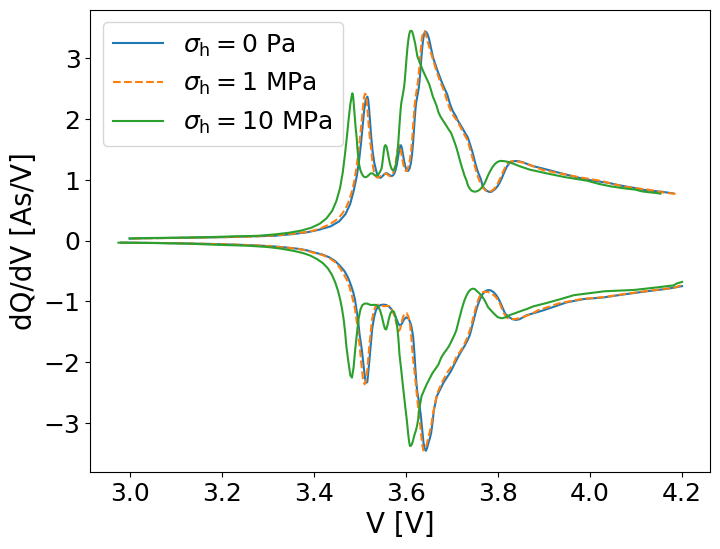

In [ ]:
dQ_dV = 1/savgol_filter(np.gradient(sol_DFN["Voltage [V]"].entries [70:], DOD[70:]),10,2)
dQ_dV_1 = 1/savgol_filter(np.gradient(sol_DFN_1["Voltage [V]"].entries[75:],DOD_1 [75:]),10,2)
dQ_dV_2 = 1/savgol_filter(np.gradient(sol_DFN_2["Voltage [V]"].entries[80:],DOD_2 [80:]),10,2)

dQ_dV_C = 1/savgol_filter(np.gradient(sol_DFN_C["Voltage [V]"].entries [102:], DOD_C[102:]),10,2)
dQ_dV_1_C = 1/savgol_filter(np.gradient(sol_DFN_1_C["Voltage [V]"].entries[111:],DOD_1_C [111:]),10,2)
dQ_dV_2_C = 1/savgol_filter(np.gradient(sol_DFN_2_C["Voltage [V]"].entries[122:],DOD_2_C [122:]),10,2)


# plot
x_val = [sol_DFN["Voltage [V]"].entries[70:],
        sol_DFN_1["Voltage [V]"].entries[75:],
        sol_DFN_2["Voltage [V]"].entries[80:],
         ]

y_val = [dQ_dV,
        dQ_dV_1,
        dQ_dV_2,
         ]

x_val_C = [sol_DFN_C["Voltage [V]"].entries[102:],
        sol_DFN_1_C["Voltage [V]"].entries[111:],
        sol_DFN_2_C["Voltage [V]"].entries[122:],
         ]

y_val_C = [dQ_dV_C,
        dQ_dV_1_C,
        dQ_dV_2_C,
         ]


plt.figure(figsize=fig_size)
cmap = plt.get_cmap('tab10')
for i in range(len(x_val)):
    color = cmap(i % 10)
    plt.plot(x_val[i], -y_val[i], label=["$\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$\sigma_{\mathrm{h}}=$1 MPa", 
                                        "$\sigma_{\mathrm{h}}=$10 MPa", 

                                                                                ][i], 
                                        linestyle=["-", "--", "-", ][i], color=color)
for i in range(len(x_val_C)):
    color = cmap(i % 6)
    plt.plot(x_val_C[i], -y_val_C[i],linestyle=["-", "--", "-", "-", "-"][i],  color=color)
    
# plt.xlim(4.15, 4.154)
# plt.ylim(-1e6, 2e6)
plt.xlabel("V [V]")
plt.ylabel("dQ/dV [As/V]")
# plt.grid()
# plt.legend(loc="center right", bbox_to_anchor=(1.4, 0.5))
plt.legend()

# save to eps
# plt.savefig("NMC_LiC6_dQdV.eps", format='eps',dpi= 300, bbox_inches='tight')


## EIS

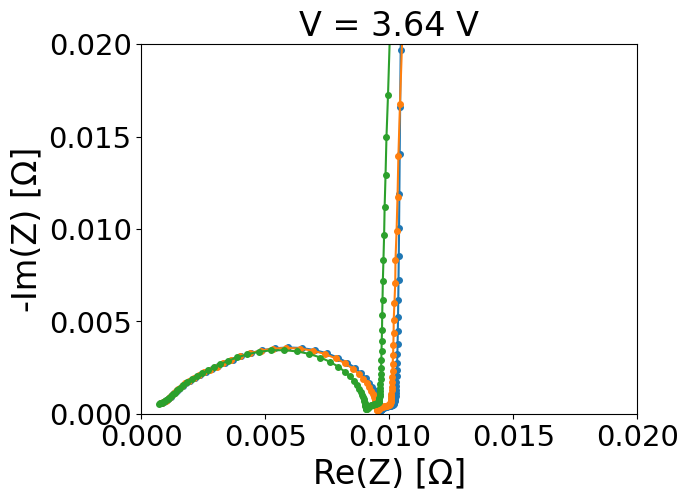

In [ ]:
Z_0Pa_soc30_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_0Pa_soc30_omgE4_lowF_Clerici.npy") 
Z_1e6Pa_soc30_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_1e6Pa_soc30_omgE4_lowF_Clerici.npy")
Z_1e7Pa_soc30_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_1e7Pa_soc30_omgE4_lowF_Clerici.npy")

plt.plot(Z_0Pa_soc30_omgE4_Clerici[:, 1], -Z_0Pa_soc30_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 0 Pa")

plt.plot(Z_1e6Pa_soc30_omgE4_Clerici[:, 1], -Z_1e6Pa_soc30_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 1 MPa")

plt.plot(Z_1e7Pa_soc30_omgE4_Clerici[:, 1], -Z_1e7Pa_soc30_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 10 MPa")


# Labels and title
# Labels and title
plt.xlabel('Re(Z) [Ω]')
plt.ylabel('-Im(Z) [Ω]')

# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.xlim(0, 0.020)
plt.ylim(0, 0.020)
plt.title('V = 3.64 V')
# plt.grid()

# save figure as eps
# plt.savefig('NMC_LiC6_Nyquist_soc30_omgE4_lowF_Clerici.eps', format='eps', dpi = 300, bbox_inches='tight')


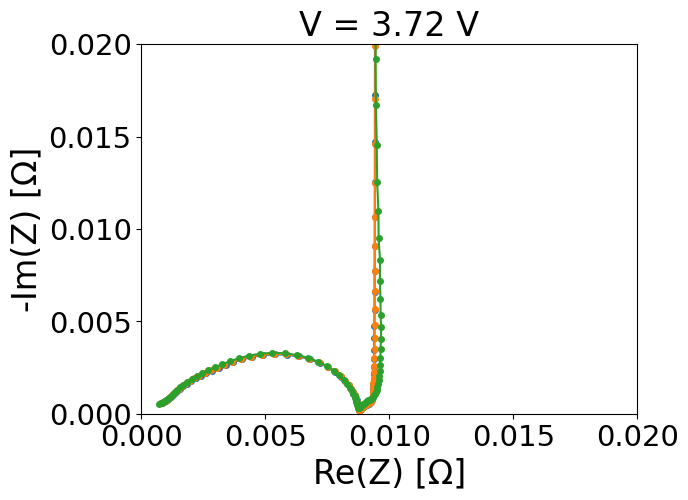

In [ ]:
Z_0Pa_soc50_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_0Pa_soc50_omgE4_lowF_Clerici.npy") 
Z_1e6Pa_soc50_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_1e6Pa_soc50_omgE4_lowF_Clerici.npy")
Z_1e7Pa_soc50_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_1e7Pa_soc50_omgE4_lowF_Clerici.npy")


plt.plot(Z_0Pa_soc50_omgE4_Clerici[:, 1], -Z_0Pa_soc50_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 0 Pa")

plt.plot(Z_1e6Pa_soc50_omgE4_Clerici[:, 1], -Z_1e6Pa_soc50_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 1 MPa")

plt.plot(Z_1e7Pa_soc50_omgE4_Clerici[:, 1], -Z_1e7Pa_soc50_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 10 MPa")


# Labels and title
plt.xlabel('Re(Z) [Ω]')
plt.ylabel('-Im(Z) [Ω]')

# plt.legend(loc='center right', bbox_to_anchor=(1.6, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.title('V = 3.72 V')
plt.xlim(0, 0.020)
plt.ylim(0, 0.020)
# plt.grid()

# save figure as eps
# plt.savefig('NMC_LiC6_Nyquist_soc50_omgE4_lowF_Clerici.eps', format='eps', dpi = 300, bbox_inches='tight')


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


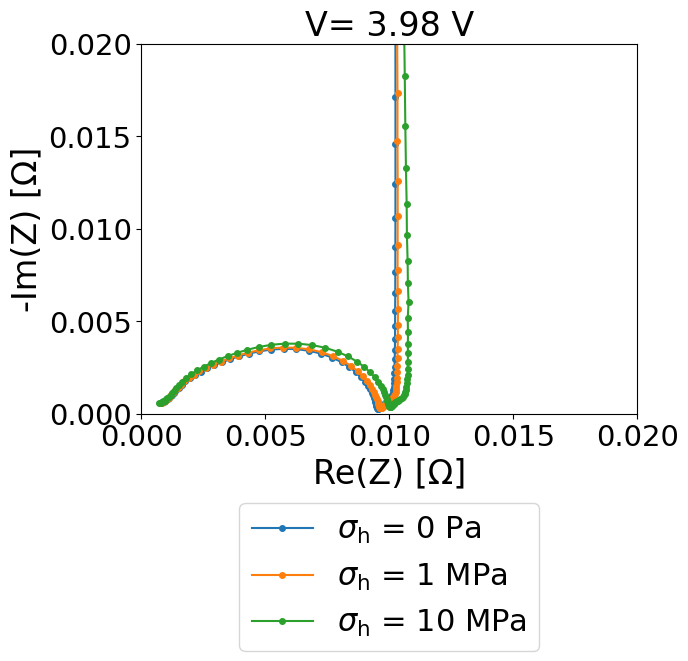

In [ ]:
Z_0Pa_soc80_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_0Pa_soc80_omgE4_lowF_Clerici.npy") 
Z_1e6Pa_soc80_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_1e6Pa_soc80_omgE4_lowF_Clerici.npy")
Z_1e7Pa_soc80_omgE4_Clerici = np.load("NMC_LiC6 results/NMC_LiC6_Z_1e7Pa_soc80_omgE4_lowF_Clerici.npy")

plt.plot(Z_0Pa_soc80_omgE4_Clerici[:, 1], -Z_0Pa_soc80_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 0 Pa")

plt.plot(Z_1e6Pa_soc80_omgE4_Clerici[:, 1], -Z_1e6Pa_soc80_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 1 MPa")

plt.plot(Z_1e7Pa_soc80_omgE4_Clerici[:, 1], -Z_1e7Pa_soc80_omgE4_Clerici[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = 10 MPa")

# Labels and title
plt.xlabel('Re(Z) [Ω]')
plt.ylabel('-Im(Z) [Ω]')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.title('V= 3.98 V')
plt.xlim(0, 0.020)
plt.ylim(0, 0.020)
# plt.grid()

# save figure as eps
# plt.savefig('NMC_LiC6_Nyquist_soc80_omgE4_lowF_Clerici.eps', format='eps', dpi = 300, bbox_inches='tight')


## DRT

In [ ]:
# read from txt
Z_0Pa_soc30_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_0Pa_soc30_omgE4_Clerici_DRT.txt")
Z_0Pa_soc50_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_0Pa_soc50_omgE4_Clerici_DRT.txt")
Z_0Pa_soc80_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_0Pa_soc80_omgE4_Clerici_DRT.txt")

Z_1e6Pa_soc30_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_1e6Pa_soc30_omgE4_Clerici_DRT.txt")
Z_1e6Pa_soc50_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_1e6Pa_soc50_omgE4_Clerici_DRT.txt")
Z_1e6Pa_soc80_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_1e6Pa_soc80_omgE4_Clerici_DRT.txt")

Z_1e7Pa_soc30_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_1e7Pa_soc30_omgE4_Clerici_DRT.txt")
Z_1e7Pa_soc50_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_1e7Pa_soc50_omgE4_Clerici_DRT.txt")
Z_1e7Pa_soc80_omgE4 = np.loadtxt("NMC_LiC6 results/NMC_LiC6_Z_1e7Pa_soc80_omgE4_Clerici_DRT.txt")

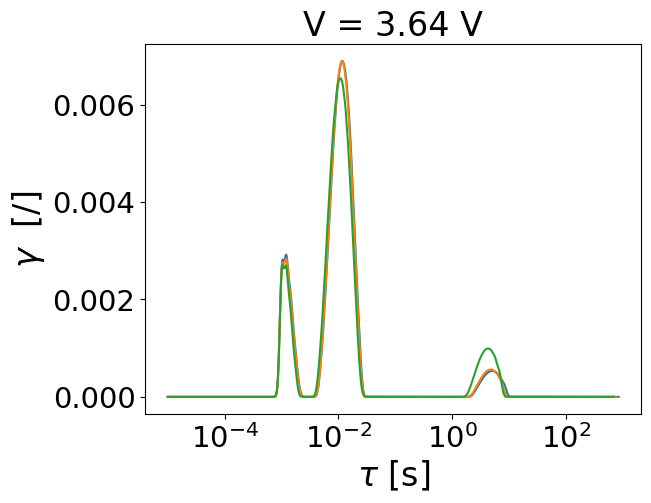

In [ ]:
# Plot DRT results
plt.plot(Z_0Pa_soc30_omgE4[:, 0], Z_0Pa_soc30_omgE4[:, 1], label='0 Pa')
plt.plot(Z_1e6Pa_soc30_omgE4[:, 0], Z_1e6Pa_soc30_omgE4[:, 1], label='1e6 Pa')
plt.plot(Z_1e7Pa_soc30_omgE4[:, 0], Z_1e7Pa_soc30_omgE4[:, 1], label='1e7 Pa')

# add logarithmic scale to x axis
plt.xscale('log')

# add labels and titlež
plt.xlabel(r'$\tau$ [s]')
plt.ylabel('$\gamma$  [/]')
plt.title('V = 3.64 V')
# plt.grid(True, which='both')
# plt.legend()

# save figure as eps
# plt.savefig('NMC_LiC6_DRT_soc30_omgE4.eps', format='eps', dpi=300, bbox_inches='tight')

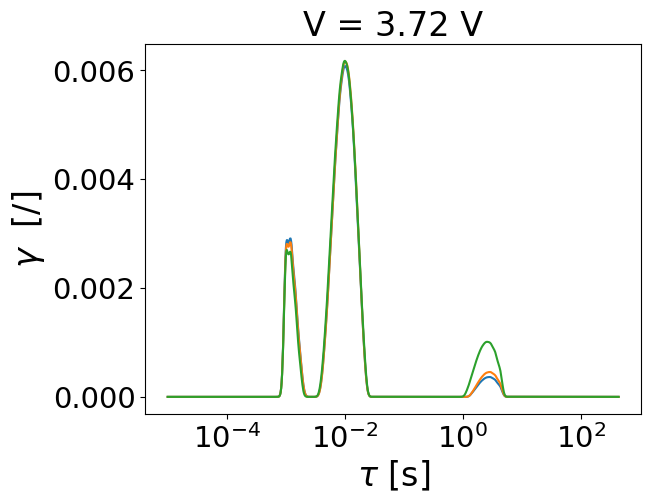

In [ ]:
# Plot DRT results
plt.plot(Z_0Pa_soc50_omgE4[:, 0], Z_0Pa_soc50_omgE4[:, 1], label='0 Pa')
plt.plot(Z_1e6Pa_soc50_omgE4[:, 0], Z_1e6Pa_soc50_omgE4[:, 1], label='1e6 Pa')
plt.plot(Z_1e7Pa_soc50_omgE4[:, 0], Z_1e7Pa_soc50_omgE4[:, 1], label='1e7 Pa')

# add logarithmic scale to x axis
plt.xscale('log')

# add labels and titlež
plt.xlabel(r'$\tau$ [s]')
plt.ylabel('$\gamma$  [/]')
plt.title('V = 3.72 V')
# plt.grid(True, which='both')
# plt.legend()

# save as eps
# plt.savefig('NMC_LiC6_DRT_soc50_omgE4.eps', format='eps', dpi=300, bbox_inches='tight')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


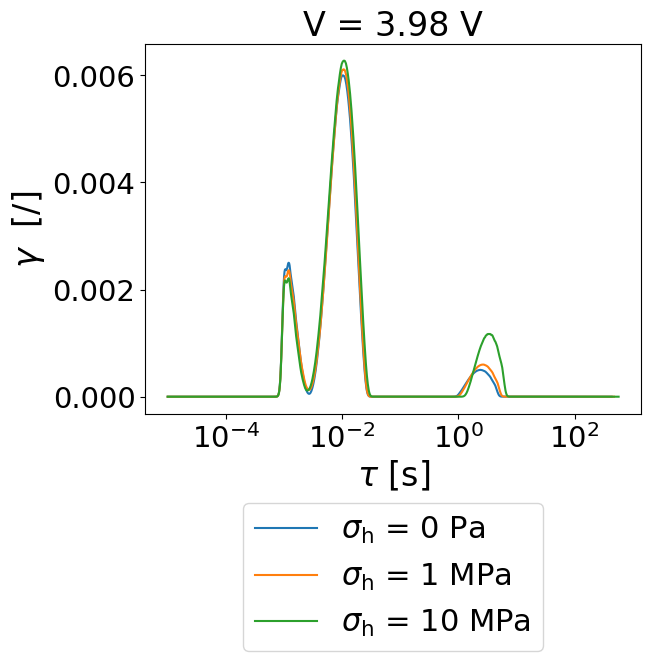

In [ ]:
# Plot DRT results
plt.plot(Z_0Pa_soc80_omgE4[:, 0], Z_0Pa_soc80_omgE4[:, 1], label='$\sigma_{{\mathrm{{h}}}}$ = 0 Pa')
plt.plot(Z_1e6Pa_soc80_omgE4[:, 0], Z_1e6Pa_soc80_omgE4[:, 1], label='$\sigma_{{\mathrm{{h}}}}$ = 1 MPa')
plt.plot(Z_1e7Pa_soc80_omgE4[:, 0], Z_1e7Pa_soc80_omgE4[:, 1], label='$\sigma_{{\mathrm{{h}}}}$ = 10 MPa')

# add logarithmic scale to x axis
plt.xscale('log')

# add labels and titlež
plt.xlabel(r'$\tau$ [s]')
plt.ylabel('$\gamma$  [/]')
plt.title('V = 3.98 V')
# plt.grid(True, which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# save as eps
# plt.savefig('NMC_LiC6_DRT_soc80_omgE4.eps', format='eps', dpi=300, bbox_inches='tight')